**Objective**

Explore the cleaned DMS dataset to understand:

Dataset characteristics
Class distribution
Missing values
Duplicate records
Dataset quality
Generate figures for the dissertation
Input
data/processed/dms_cleaned.csv
Outputs
reports/

├── figures/
│      class_distribution.png
│      class_distribution_pie.png
│      missing_values.png
│
├── eda_summary.csv
└── metadata_statistics.csv

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [2]:
PROJECT_DIR = Path("/workspaces/DBA-ai-trust-score-framework-Interim")

PROCESSED_DIR = PROJECT_DIR / "data" / "processed"

REPORT_DIR = PROJECT_DIR / "reports"

FIGURE_DIR = REPORT_DIR / "figures"

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [3]:
metadata = pd.read_csv(
    PROCESSED_DIR / "dms_cleaned.csv"
)

metadata.head()

,file_name,label,dataset,original_path
0,gB_7_s2_2019-03-11T14-12-25-01-00_ir_face_mp4-...,DangerousDriving,Thesis_dataset2,../data/raw/Thesis_dataset2/DangerousDriving/g...
1,gA_4_s2_ir_face_mp4-372_jpg.rf.448fec2e90c845f...,DangerousDriving,Thesis_dataset2,../data/raw/Thesis_dataset2/DangerousDriving/g...
2,gA_5_s2_ir_face_mp4-130_jpg.rf.1081aec5f8fd8da...,DangerousDriving,Thesis_dataset2,../data/raw/Thesis_dataset2/DangerousDriving/g...
3,gB_9_s2_2019-03-07T16-21-20-01-00_ir_face_mp4-...,DangerousDriving,Thesis_dataset2,../data/raw/Thesis_dataset2/DangerousDriving/g...
4,gA_5_s2_ir_face_mp4-246_jpg.rf.f7bcf481f361e68...,DangerousDriving,Thesis_dataset2,../data/raw/Thesis_dataset2/DangerousDriving/g...


In [4]:
print("="*60)

print("Dataset Overview")

print("="*60)

print(f"Rows    : {metadata.shape[0]}")

print(f"Columns : {metadata.shape[1]}")

print()

metadata.info()

Dataset Overview
Rows    : 1400
Columns : 4

<class 'pandas.DataFrame'>
RangeIndex: 1400 entries, 0 to 1399
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   file_name      1400 non-null   str  
 1   label          1400 non-null   str  
 2   dataset        1400 non-null   str  
 3   original_path  1400 non-null   str  
dtypes: str(4)
memory usage: 269.2 KB


In [5]:
statistics = metadata.describe(include="all").T

statistics.to_csv(
    REPORT_DIR / "metadata_statistics.csv"
)

statistics

,count,unique,top,freq
file_name,1400,1398,_59.png,2
label,1400,7,DangerousDriving,200
dataset,1400,1,Thesis_dataset2,1400
original_path,1400,1400,../data/raw/Thesis_dataset2/DangerousDriving/g...,1


/tmp/ipykernel_13813/3124586744.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


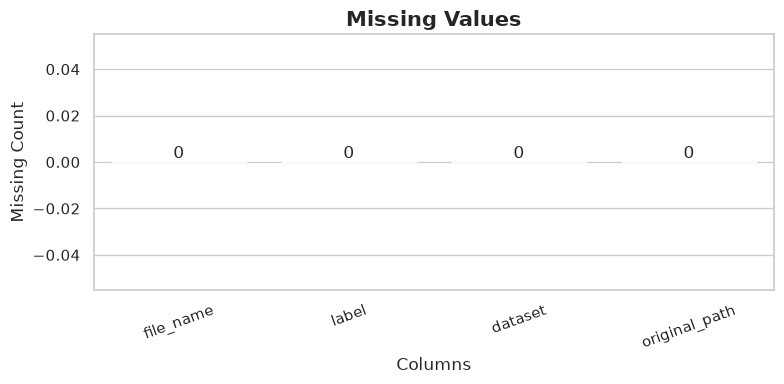

In [6]:
missing = metadata.isnull().sum()

missing = missing.sort_values(
    ascending=False
)

plt.figure(figsize=(8,4))

ax = sns.barplot(
    x=missing.index,
    y=missing.values,
    palette="Reds"
)

plt.title(
    "Missing Values",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Columns")

plt.ylabel("Missing Count")

plt.xticks(rotation=20)

for p in ax.patches:

    ax.annotate(
        str(int(p.get_height())),
        (
            p.get_x()+p.get_width()/2,
            p.get_height()
        ),
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "missing_values.png",
    dpi=300
)

plt.show()

In [7]:
duplicates = metadata.duplicated().sum()

print(f"Duplicate Records : {duplicates}")

Duplicate Records : 0


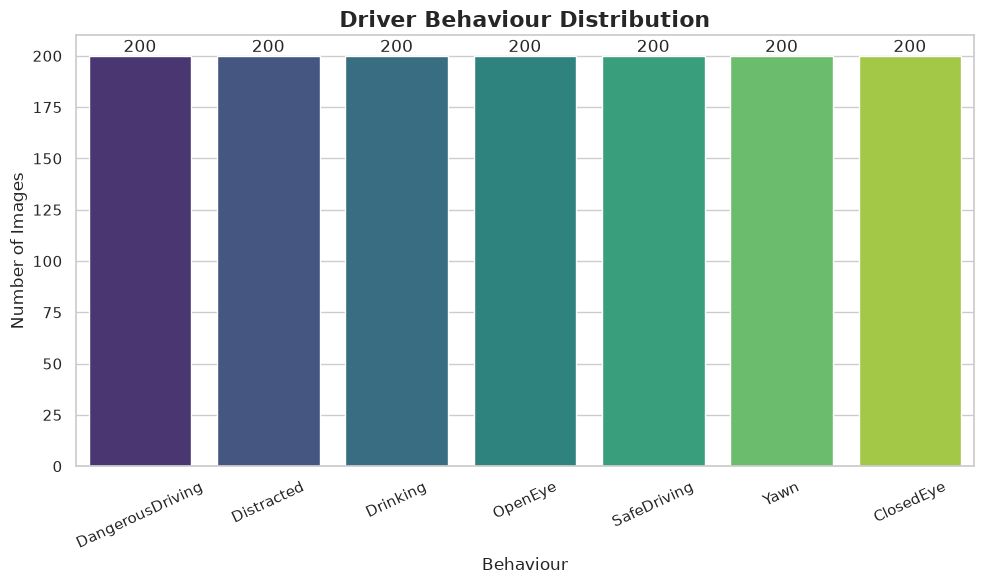

In [8]:
plt.figure(figsize=(10,6))

ax = sns.countplot(

    data=metadata,

    x="label",

    order=metadata["label"].value_counts().index,

    hue="label",

    palette="viridis",

    legend=False

)

plt.title(

    "Driver Behaviour Distribution",

    fontsize=16,

    fontweight="bold"

)

plt.xlabel("Behaviour")

plt.ylabel("Number of Images")

plt.xticks(rotation=25)

for p in ax.patches:

    ax.annotate(

        str(int(p.get_height())),

        (

            p.get_x()+p.get_width()/2,

            p.get_height()

        ),

        ha="center",

        va="bottom"

    )

plt.tight_layout()

plt.savefig(

    FIGURE_DIR/"class_distribution.png",

    dpi=300

)

plt.show()

____________________________ Behavior Percentage _____________________________

In [9]:
distribution = (

    metadata["label"]

    .value_counts(normalize=True)

    .mul(100)

    .round(2)

)

distribution

label
DangerousDriving    14.29
Distracted          14.29
Drinking            14.29
OpenEye             14.29
SafeDriving         14.29
Yawn                14.29
ClosedEye           14.29
Name: proportion, dtype: float64

________________________________ Pie Chart ___________________________________

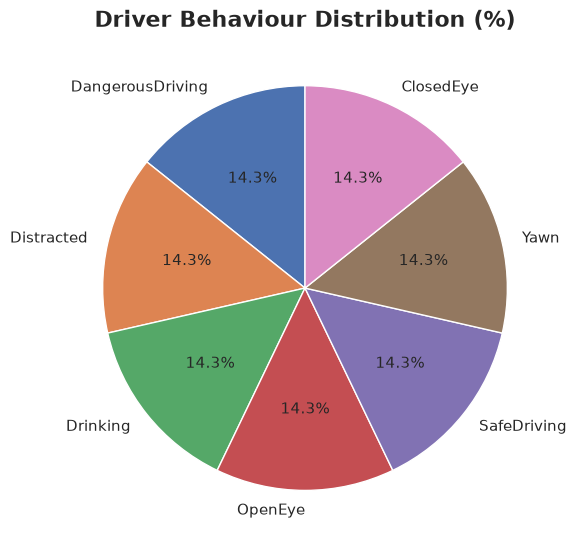

In [10]:
plt.figure(figsize=(6,6))

metadata["label"].value_counts().plot(

    kind="pie",

    autopct="%1.1f%%",

    startangle=90,

    textprops={"fontsize":11}

)

plt.ylabel("")

plt.title(

    "Driver Behaviour Distribution (%)",

    fontsize=16,

    fontweight="bold"

)

plt.tight_layout()

plt.savefig(

    FIGURE_DIR/"class_distribution_pie.png",

    dpi=300

)

plt.show()

_____________________________________ EDA Summary ___________________________________

In [11]:
eda_summary = pd.DataFrame({

    "Metric":[

        "Total Images",

        "Behaviour Classes",

        "Missing Values",

        "Duplicate Records"

    ],

    "Value":[

        len(metadata),

        metadata["label"].nunique(),

        metadata.isnull().sum().sum(),

        metadata.duplicated().sum()

    ]

})

eda_summary

,Metric,Value
0,Total Images,1400
1,Behaviour Classes,7
2,Missing Values,0
3,Duplicate Records,0


In [12]:
eda_summary.to_csv(

    REPORT_DIR / "eda_summary.csv",

    index=False

)

print("EDA Summary Saved")

EDA Summary Saved
